# Fixation Elman mRNN Smoke Test

This notebook is the minimal end-to-end workflow for fitting the fixation mRNN to two target spaces:

1. Raw mean firing-rate time series.
2. Per-region firing-rate PCs.

The code uses a fixed region order from `configs/ephys_fixation_mrnn.yaml`. Output dimensions are inferred from the target tensors, so raw firing-rate models read out the number of units in each region and PC models read out the retained PC dimensions for each region.

## 1. Setup

Use the local repository code and load the compact modeling API.

In [1]:
from pathlib import Path
from io import BytesIO
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())

import sys
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from dal_monte_2022_analysis.ephys.modeling import (
    extract_region_currents,
    load_fixation_mrnn_config,
    make_targets,
    output_pc_scores,
    reconstruction_accuracy,
    replay_fixation_mrnn_run,
    settings_from_config,
    train_fixation_mrnn_scratch,
    variance_comparison,
)
from dal_monte_2022_analysis.ephys.plotting import (
    FixationMRNNDiagnosticPlotSettings,
    plot_fixation_mrnn_average_current_influence_bars,
    plot_fixation_mrnn_flow_fields_at_time,
    plot_fixation_mrnn_signal_evolution,
)


def display_figure(fig, *, dpi=90):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(6.8, 3.4), dpi=130)
    loss_columns = [
        ("loss", "total"),
        ("reconstruction_loss", "pointwise reconstruction"),
        ("mse_loss", "pointwise reconstruction"),
        ("temporal_derivative_loss", "temporal derivative"),
        ("temporal_curvature_loss", "temporal curvature"),
        ("rate_loss", "L1 rate"),
        ("weight_loss", "L1 weight"),
    ]
    seen_labels = set()
    for column, label in loss_columns:
        if column not in history or label in seen_labels:
            continue
        seen_labels.add(label)
        ax.plot(history["iteration"], history[column], label=label)
    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    display_figure(fig)
    return fig, ax


def plot_reconstructions(replay, title, max_features=2):
    checkpoint = replay["checkpoint"]
    regions = tuple(replay["region_order"])
    conditions = tuple(replay["condition_order"])
    time = np.asarray(checkpoint["timeline_s"], dtype=float)
    fig, axes = plt.subplots(len(regions), max_features, figsize=(4.2 * max_features, 2.1 * len(regions)), dpi=130, squeeze=False)
    for row, region in enumerate(regions):
        observed = np.asarray(checkpoint["target_by_region"][region], dtype=float)
        predicted = replay["output_by_region"][region].detach().cpu().numpy()
        feature_names = checkpoint["features_by_region"][region]
        for feature_idx in range(max_features):
            ax = axes[row, feature_idx]
            if feature_idx >= observed.shape[-1]:
                ax.axis("off")
                continue
            color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
            for cond_idx, condition in enumerate(conditions):
                color = color_cycle[cond_idx % len(color_cycle)] if color_cycle else None
                ax.plot(
                    time,
                    observed[cond_idx, :, feature_idx],
                    color=color,
                    linewidth=1.5,
                    linestyle="-",
                    label=f"{condition} observed",
                )
                ax.plot(
                    time,
                    predicted[cond_idx, :, feature_idx],
                    color=color,
                    linestyle=":",
                    linewidth=1.8,
                    label=f"{condition} mRNN",
                )
            ax.set_title(f"{region}: {feature_names[feature_idx]}", fontsize=9)
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Target")
            ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=7)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    display_figure(fig)
    return fig, axes


def plot_output_pcs(replay, title):
    regions = tuple(replay["region_order"])
    conditions = tuple(replay["condition_order"])
    time = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    fig, axes = plt.subplots(len(regions), len(conditions), figsize=(11, 7), dpi=130, squeeze=False, sharex=True)
    for row, region in enumerate(regions):
        scores = output_pc_scores(replay, region=region, n_components=3)
        for col, condition in enumerate(conditions):
            ax = axes[row, col]
            cond_idx = conditions.index(condition)
            for pc_idx, linestyle in enumerate(("-", "--", ":")):
                ax.plot(time, scores[cond_idx, :, pc_idx], linestyle=linestyle, label=f"PC{pc_idx + 1}")
            if row == 0:
                ax.set_title(condition)
            if col == 0:
                ax.set_ylabel(f"{region}\nscore")
            if row == len(regions) - 1:
                ax.set_xlabel("Time (s)")
    axes[0, -1].legend(frameon=False, fontsize=7)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    display_figure(fig)
    return fig, axes


def summarize_replay(replay):
    current_df, current_vectors = extract_region_currents(replay)
    display(reconstruction_accuracy(replay))
    display(variance_comparison(replay))
    display(current_df.groupby(["target_region", "source_region"], as_index=False)["relative_contribution"].mean())
    return current_df, current_vectors

def summarize_replay(replay):
    current_df, current_vectors = extract_region_currents(replay)
    display(reconstruction_accuracy(replay))
    display(variance_comparison(replay))
    display(
        current_df.groupby(["target_region", "source_region"], as_index=False)
        .agg(
            mean_signed_projection=("signed_projection", "mean"),
            mean_signed_relative_contribution=("relative_contribution", "mean"),
        )
    )
    return current_df, current_vectors


def show_function_source(function, *, max_lines=80):
    source = inspect.getsource(function).splitlines()[:max_lines]
    print("\n".join(f"{idx + 1:03d}: {line}" for idx, line in enumerate(source)))


## 2. Model Definition and Equations

The model is an Elman mRNN. For condition plus temporal-basis input $u_t$, hidden activity $h_t$, and region-specific readout $\hat y^r_t$, the forward pass is:

$$h_{t+1}=\phi(W_{rec}h_t + W_{in}u_t + b + \epsilon_t)$$

$$\hat y^r_t = W^r_{out}h^r_t + b^r_{out}$$

There is no separate latent/preactivation state in this simplified pipeline. The model stores the Elman hidden sequence and per-region readout outputs.

### Why temporal Gaussian channels are included

A condition-only input is constant over the whole fixation-aligned window. With a constant input, an Elman RNN can settle into one fixed point per fixation category. Loss may still fall because the readout can fit the condition mean or broad offsets, but the model is not forced to reconstruct PSTH shape. The temporal Gaussian channels add smooth time-localized inputs shared across conditions:

$$u_t = [\text{condition one-hot}, g_1(t), g_2(t), \ldots, g_K(t)]$$

Each $g_k(t)$ is a Gaussian centered at a different time bin. We currently use 20 channels, so the input provides a finer code for where the model is within the -500 ms to +500 ms fixation window. These channels help the model express fast, 10s-of-ms changes in the output, but they can also let the network become input driven. That is why the loss now explicitly rewards reconstructed output dynamics, not only pointwise level matching.

### Loss used to favor temporal dynamics

The fitted objective is:

$$\mathcal{L}=\mathcal{L}_{point}+\lambda_{\Delta}\mathcal{L}_{\Delta}+\lambda_{\Delta^2}\mathcal{L}_{\Delta^2}+\lambda_h\|h\|_1+\lambda_W\|W\|_1$$

The pointwise term fits target values:

$$\mathcal{L}_{point}=\frac{1}{N}\sum_{c,t,j}w_t(\hat y_{c,t,j}-y_{c,t,j})^2$$

The first-difference term fits changes between adjacent 10 ms bins:

$$\mathcal{L}_{\Delta}=\frac{1}{N}\sum_{c,t,j}w_t\left[(\hat y_{c,t,j}-\hat y_{c,t-1,j})-(y_{c,t,j}-y_{c,t-1,j})\right]^2$$

The optional curvature term fits second differences:

$$\mathcal{L}_{\Delta^2}=\frac{1}{N}\sum_{c,t,j}w_t\left[\Delta^2\hat y_{c,t,j}-\Delta^2 y_{c,t,j}\right]^2$$

The default uses `temporal_derivative_loss_scale = 1.0` and `temporal_curvature_loss_scale = 0.0`. The derivative term makes falling loss depend on matching temporal slopes, which should reduce the flat-line solution where aggregate metrics look good but dynamics are poor. Curvature can be turned on if the model still smooths sharp accelerations too much.

The weights $w_t$ are defined from the fixation-aligned timeline. By default pre-fixation (-500 to 0 ms) and post-fixation (0 to 500 ms) bins have equal weight. If the scientific question focuses on anticipatory/pre-fixation state or post-onset visual/social responses, `pre_fixation_loss_weight` and `post_fixation_loss_weight` can tilt the objective without changing the data tensor.

### Current extraction and signed contribution

Current extraction in `extract_region_currents` uses the effective recurrent matrix after masks and constraints. For target region $r$ and source region $s$, the function slices the recurrent block $W_{rec}^{r,s}$ and multiplies it by the previous hidden activity of the source region:

$$I_{s\to r}(t)=W_{rec}^{r,s}h^s_{t-1}$$

The relative contribution is signed. We project each source current onto the next target-region activity vector, so aligned currents are positive and opposing currents are negative:

$$p_{s\to r}(t)=\frac{I_{s\to r}(t)\cdot h^r_t}{\|h^r_t\|_2}$$

$$C_{s\to r}(t)=\frac{p_{s\to r}(t)}{\sum_q |p_{q\to r}(t)|}$$

Because $C_{s\to r}(t)$ is signed, pie charts are not appropriate. We use over-time signed curves/fills and time-averaged diverging bars.

### PC target weighting

PCA targets use the smallest shared number of PCs needed so every region reaches at least 95% explained variance. This keeps each region equally weighted in the PC target space. PCA trajectories, flow fields, and downstream summaries in this notebook are computed from the model readout outputs or hidden trajectories generated by the model, not from unobserved latent-state variables.

### Why flow fields can look like point attractors

The flow-field plot freezes the external input at one selected time bin and examines one-step hidden updates around that state. The PC axes are fit on the full hidden state across all regions, so separate regional panels are comparable. Each regional panel then projects only that region's slice of the hidden displacement into the shared PC space. If the learned recurrent dynamics are locally stable, or if the temporal Gaussian inputs carry most of the timing information, the field can still look like a point attractor. That suggests the fit is input/readout driven. The derivative loss, optional curvature loss, post/pre weighting, reduced temporal-basis strength, brief-cue inputs, or stronger recurrent-dynamics constraints are the main knobs to test if we want richer internally generated trajectories.


In [2]:
cfg = load_fixation_mrnn_config(repo_root / "configs" / "ephys_fixation_mrnn.yaml")
settings = settings_from_config(cfg)
settings.dataset_cfg_path = str(repo_root / "configs" / "dataset.yaml")
settings.device = "auto"
settings.hidden_units = 50
settings.epochs = 10_000
settings.initialization_mode = "single"
settings.overwrite_seed_plan = False
settings

FixationMRNNRunSettings(dataset_cfg_path='/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/configs/dataset.yaml', input_subdir='ephys/psth/fixation_psth_averages', dataframe_filename='fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl', timeline_filename='fixations_psth_10ms_bin_centers_s_rel_window_neg500ms_to_pos500ms.pkl', output_subdir='ephys/modeling/fixation_mrnn', region_order=('ofc', 'bla', 'dmpfc', 'accg'), condition_order=('face_interactive', 'face_non_interactive', 'object'), target_mode='raw_fr', normalize_targets=True, normalization_stabilizer=5.0, pca_variance_threshold=0.95, temporal_basis_count=20, hidden_units=50, activation='softplus', spectral_radius=1.3, rec_constrained=False, inp_constrained=False, batch_first=True, inp_noise=0.0, act_noise=0.0, epochs=10000, lr=0.001, loss_fn='mse', temporal_derivative_loss_scale=1.0, temporal_curvature_loss_scale=0.5, pre_fixation_loss_weight=1.0, post_fixation_loss_weight=1.0, l1_weight_scale=0.0, l1_r

## 3. Technical Audit of Transformations

This section reports the transformations and objective before fitting. It is meant to make the model behavior debuggable: what enters the RNN, what target space is used, how normalization is applied, what the loss contains, and which code paths implement each step.

In [3]:
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_targets import build_condition_input, build_fixation_mrnn_targets_from_dataframe
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_training import _temporal_difference_loss, _time_weights, make_targets, train_one_initialization
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_analysis import extract_region_currents

print("Config choices that affect data/model/training")
display(pd.DataFrame([
    {"decision": "region order", "value": settings.region_order},
    {"decision": "condition order", "value": settings.condition_order},
    {"decision": "global normalization stabilizer", "value": settings.normalization_stabilizer},
    {"decision": "temporal Gaussian channels", "value": settings.temporal_basis_count},
    {"decision": "PCA variance threshold", "value": settings.pca_variance_threshold},
    {"decision": "hidden units per region", "value": settings.hidden_units},
    {"decision": "loss", "value": settings.loss_fn},
    {"decision": "temporal derivative loss scale", "value": settings.temporal_derivative_loss_scale},
    {"decision": "temporal curvature loss scale", "value": settings.temporal_curvature_loss_scale},
    {"decision": "pre-fixation loss weight", "value": settings.pre_fixation_loss_weight},
    {"decision": "post-fixation loss weight", "value": settings.post_fixation_loss_weight},
    {"decision": "L1 weight scale", "value": settings.l1_weight_scale},
    {"decision": "L1 rate scale", "value": settings.l1_rate_scale},
    {"decision": "train initial state", "value": settings.train_initial_state},
]))

print("\nInput construction snippet")
show_function_source(build_condition_input, max_lines=55)

print("\nTarget construction snippet")
show_function_source(build_fixation_mrnn_targets_from_dataframe, max_lines=90)

print("\nTemporal weighting and derivative-loss snippets")
show_function_source(_time_weights, max_lines=55)
show_function_source(_temporal_difference_loss, max_lines=70)

print("\nTraining/loss snippet")
show_function_source(train_one_initialization, max_lines=145)

print("\nCurrent extraction snippet")
show_function_source(extract_region_currents, max_lines=110)

Config choices that affect data/model/training


,decision,value
0,region order,"(ofc, bla, dmpfc, accg)"
1,condition order,"(face_interactive, face_non_interactive, object)"
2,global normalization stabilizer,5.0
3,temporal Gaussian channels,20
4,PCA variance threshold,0.95
5,hidden units per region,50
6,loss,mse
7,temporal derivative loss scale,1.0
8,temporal curvature loss scale,0.5
9,pre-fixation loss weight,1.0



Input construction snippet
001: def build_condition_input(
002:     condition_order: tuple[str, ...],
003:     *,
004:     timesteps: int,
005:     temporal_basis_count: int = 20,
006: ) -> np.ndarray:
007:     """Return condition x time x input with condition and temporal channels."""
008:     channel = {condition: idx for idx, condition in enumerate(CONDITION_ORDER)}
009:     n_temporal = max(0, int(temporal_basis_count))
010:     out = np.zeros(
011:         (len(condition_order), int(timesteps), len(CONDITION_ORDER) + n_temporal),
012:         dtype=np.float32,
013:     )
014:     for cond_idx, condition in enumerate(condition_order):
015:         out[cond_idx, :, channel[condition]] = 1.0
016:     if n_temporal:
017:         time = np.linspace(-1.0, 1.0, int(timesteps), dtype=np.float32)
018:         centers = np.linspace(-1.0, 1.0, n_temporal, dtype=np.float32)
019:         if n_temporal == 1:
020:             width = 1.0
021:         else:
022:             width = float(centers

## 4. Targets

Targets are built once from the combined fixation PSTH export. Raw firing rates are normalized with one global robust scale across all regions, units, fixation types, and time bins before either raw targets or region PCs are used for fitting.

In [4]:
targets = make_targets(settings)
rows = []
for region in targets.region_order:
    rows.append({
        "region": region,
        "raw_shape": targets.raw_by_region[region].shape,
        "pc_shape": targets.pcs_by_region[region].shape,
        "raw_units": targets.raw_by_region[region].shape[-1],
        "shared_pc_dims": targets.pcs_by_region[region].shape[-1],
        "pcs_required_for_95pct": targets.pca_by_region[region].n_components_required,
        "raw_variance": float(np.var(targets.raw_by_region[region])),
        "pc_variance": float(np.var(targets.pcs_by_region[region])),
    })

print("Transformations before fitting")
print(f"1. Combined PSTH rows are reshaped into condition x time x unit tensors for each region.")
print(f"2. Raw firing rates are divided by one global robust scale: {targets.normalization_scale:.6g}")
print(f"3. Model input has shape {targets.input_tensor.shape}: 3 condition channels + {settings.temporal_basis_count} Gaussian temporal channels.")
print("4. Region PC targets are fit after global normalization, then padded to a shared PC count across regions.")
print("5. Training loss is weighted pointwise reconstruction + temporal derivative loss + optional curvature loss + L1 terms.")
print(f"   pre/post fixation weights = {settings.pre_fixation_loss_weight:g}/{settings.post_fixation_loss_weight:g}; derivative scale = {settings.temporal_derivative_loss_scale:g}; curvature scale = {settings.temporal_curvature_loss_scale:g}")
display(pd.DataFrame(rows))

Transformations before fitting
1. Combined PSTH rows are reshaped into condition x time x unit tensors for each region.
2. Raw firing rates are divided by one global robust scale: 24.3633
3. Model input has shape (3, 100, 23): 3 condition channels + 20 Gaussian temporal channels.
4. Region PC targets are fit after global normalization, then padded to a shared PC count across regions.
5. Training loss is weighted pointwise reconstruction + temporal derivative loss + optional curvature loss + L1 terms.
   pre/post fixation weights = 1/1; derivative scale = 1; curvature scale = 0.5


,region,raw_shape,pc_shape,raw_units,shared_pc_dims,pcs_required_for_95pct,raw_variance,pc_variance
0,ofc,"(3, 100, 241)","(3, 100, 42)",241,42,38,0.088571,0.013428
1,bla,"(3, 100, 537)","(3, 100, 42)",537,42,42,0.076788,0.024063
2,dmpfc,"(3, 100, 187)","(3, 100, 42)",187,42,33,0.056762,0.008286
3,accg,"(3, 100, 236)","(3, 100, 42)",236,42,40,0.032082,0.005290


## 5. Raw Firing-Rate Fit

This section fits the model readouts directly to normalized mean firing-rate traces. The output dimension for each region is the number of recorded units in that region.

raw_fr seed=211382628:   0%|          | 0/10000 [00:00<?, ?iter/s]

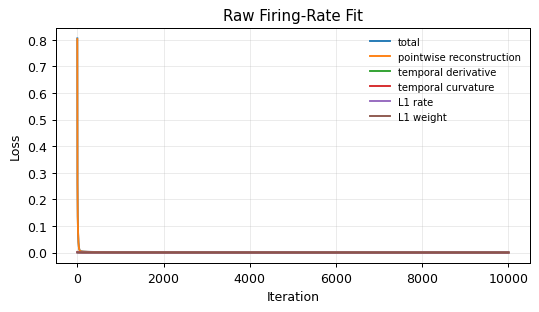

,iteration,loss,reconstruction_loss,mse_loss,temporal_derivative_loss,temporal_curvature_loss,rate_loss,weight_loss
9995,9996,0.000213,0.000147,0.000147,0.000053,0.000026,0.0,0.0
9996,9997,0.000214,0.000148,0.000148,0.000053,0.000026,0.0,0.0
9997,9998,0.000214,0.000148,0.000148,0.000053,0.000026,0.0,0.0
9998,9999,0.000214,0.000148,0.000148,0.000053,0.000026,0.0,0.0
9999,10000,0.000213,0.000147,0.000147,0.000053,0.000026,0.0,0.0


Raw input shape saved in checkpoint: (3, 100, 23)


,region,condition,mse,mae,r2,correlation
0,ofc,face_interactive,0.000148,0.008652,0.998391,0.999195
1,ofc,face_non_interactive,0.000223,0.010687,0.997446,0.998722
2,ofc,object,0.000199,0.010177,0.997689,0.998845
3,bla,face_interactive,0.000131,0.008185,0.998305,0.999153
4,bla,face_non_interactive,0.000176,0.009398,0.997598,0.998800
5,bla,object,0.000160,0.008780,0.997998,0.998999
6,dmpfc,face_interactive,0.000096,0.007088,0.998325,0.999162
7,dmpfc,face_non_interactive,0.000133,0.008537,0.997730,0.998865
8,dmpfc,object,0.000155,0.008837,0.997134,0.998566
9,accg,face_interactive,0.000082,0.006542,0.997516,0.998757


,region,observed_variance,reconstructed_variance,reconstructed_to_observed_ratio
0,ofc,0.088571,0.088358,0.997589
1,bla,0.076788,0.076759,0.999631
2,dmpfc,0.056762,0.056594,0.997043
3,accg,0.032082,0.031957,0.996097


,target_region,source_region,mean_signed_projection,mean_signed_relative_contribution
0,accg,accg,0.129761,0.024189
1,accg,bla,-0.824087,-0.374986
2,accg,dmpfc,-0.512005,-0.223246
3,accg,ofc,0.018666,-0.072109
4,bla,accg,-0.136281,-0.038904
5,bla,bla,0.105503,0.078965
6,bla,dmpfc,-0.427723,-0.182983
7,bla,ofc,1.238230,0.468869
8,dmpfc,accg,-0.066812,0.007212
9,dmpfc,bla,-0.250103,-0.076027


In [5]:
raw_settings = settings_from_config(cfg)
raw_settings.dataset_cfg_path = settings.dataset_cfg_path
raw_settings.device = settings.device
raw_settings.hidden_units = settings.hidden_units
raw_settings.epochs = settings.epochs
raw_settings.initialization_mode = "single"
raw_settings.target_mode = "raw_fr"
raw_settings.seed = 123456

raw_result = train_fixation_mrnn_scratch(raw_settings, scratch_id="smoke_raw_fr", overwrite=True)
plot_loss(raw_result["history"], "Raw Firing-Rate Fit")
display(raw_result["history"].tail())
raw_replay = replay_fixation_mrnn_run(raw_result["run_dir"], device="auto")
print("Raw input shape saved in checkpoint:", raw_replay["checkpoint"]["input_tensor"].shape)
raw_current_df, raw_current_vectors = summarize_replay(raw_replay)

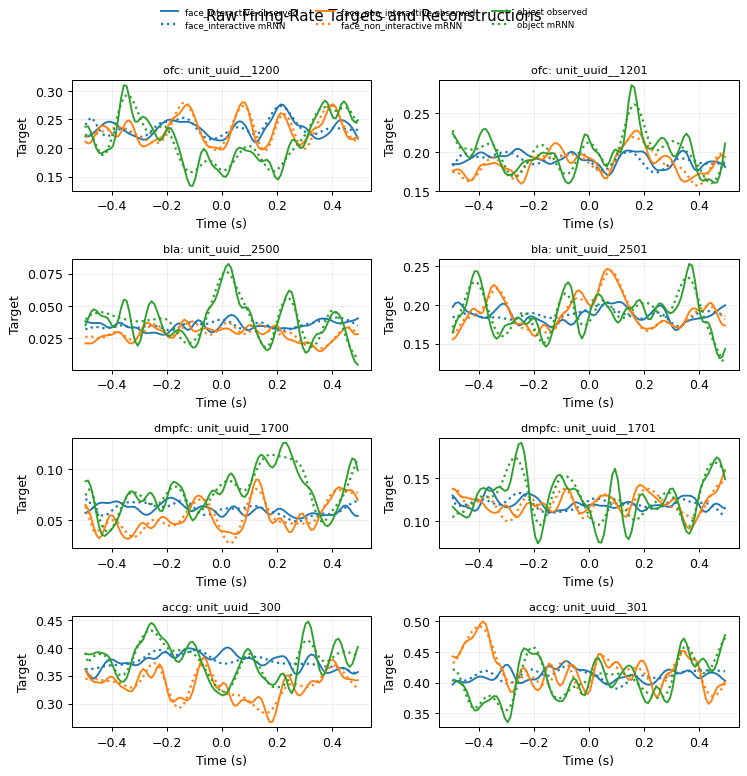

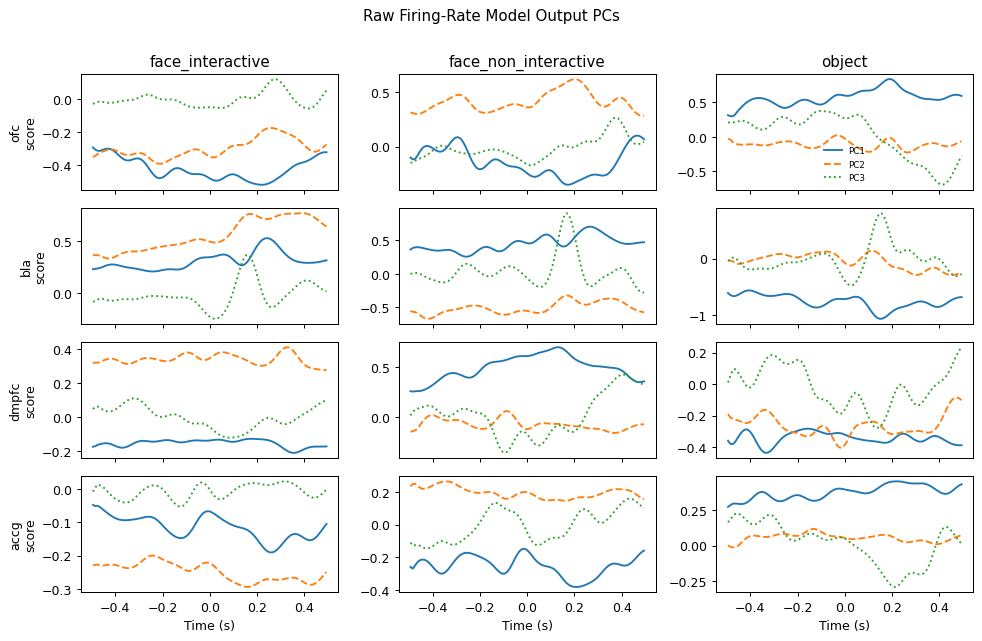

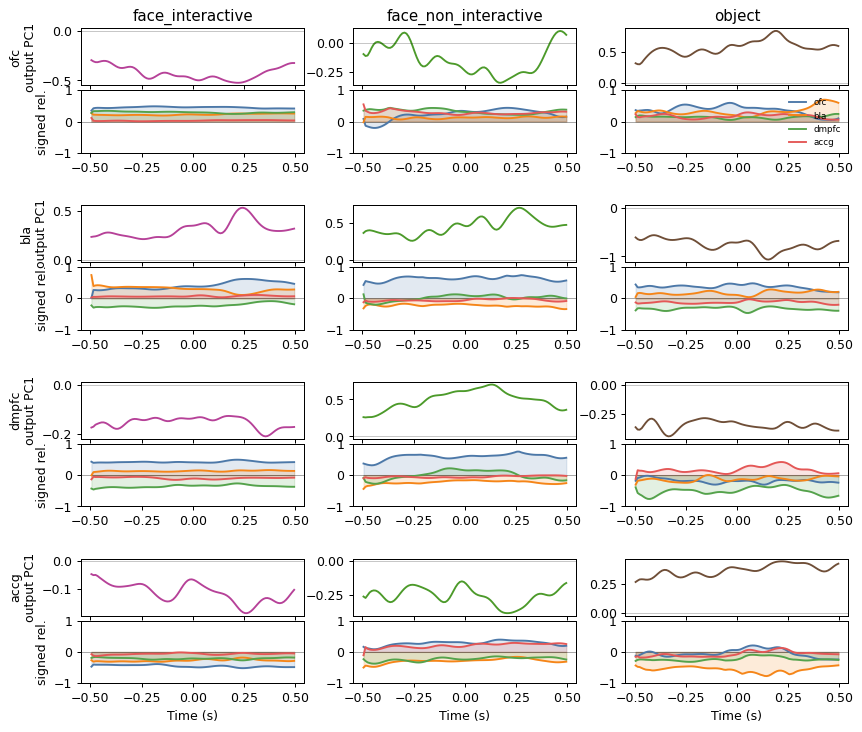

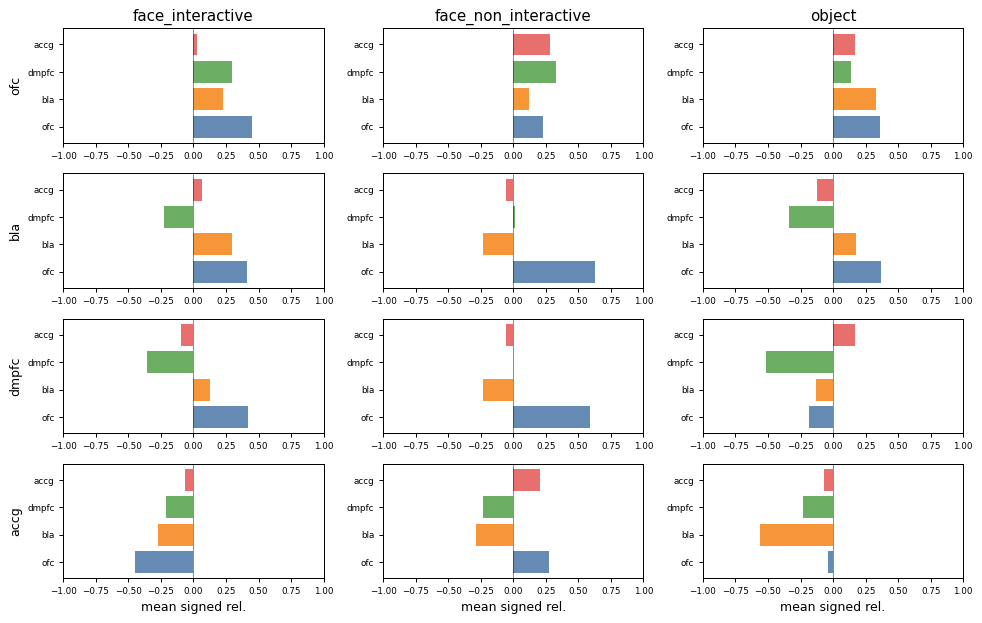

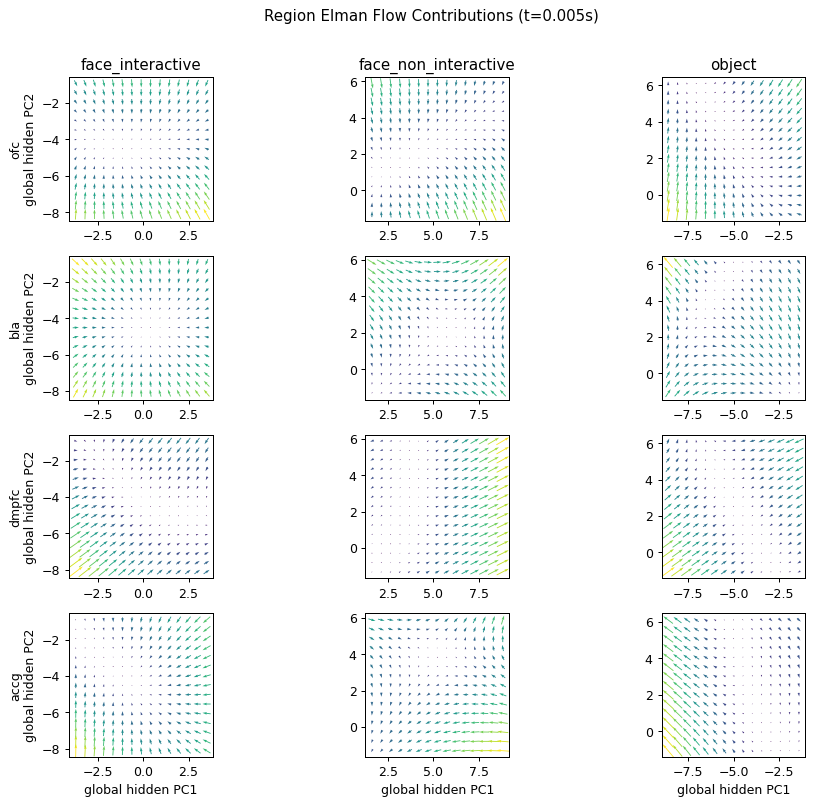

In [6]:
plot_settings = FixationMRNNDiagnosticPlotSettings()
plot_reconstructions(raw_replay, "Raw Firing-Rate Targets and Reconstructions", max_features=2)
plot_output_pcs(raw_replay, "Raw Firing-Rate Model Output PCs")
raw_signal_fig, raw_signal_axes = plot_fixation_mrnn_signal_evolution(raw_replay, settings=plot_settings)
display_figure(raw_signal_fig)
raw_bar_fig, raw_bar_axes = plot_fixation_mrnn_average_current_influence_bars(raw_replay, settings=plot_settings)
display_figure(raw_bar_fig)
raw_flow_fig, raw_flow_axes = plot_fixation_mrnn_flow_fields_at_time(raw_replay, settings=plot_settings, grid_points=15)
display_figure(raw_flow_fig)

## 6. Firing-Rate PC Fit

This section fits the same Elman mRNN architecture to per-region PCs. PC dimensions are inferred from the PCA threshold and can differ by region.

region_pcs seed=671176043:   0%|          | 0/10000 [00:00<?, ?iter/s]

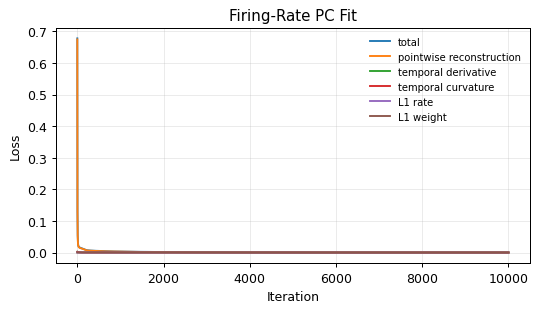

,iteration,loss,reconstruction_loss,mse_loss,temporal_derivative_loss,temporal_curvature_loss,rate_loss,weight_loss
9995,9996,0.000137,0.000084,0.000084,0.000040,0.000027,0.0,0.0
9996,9997,0.000137,0.000084,0.000084,0.000039,0.000027,0.0,0.0
9997,9998,0.000137,0.000084,0.000084,0.000040,0.000027,0.0,0.0
9998,9999,0.000138,0.000085,0.000085,0.000040,0.000027,0.0,0.0
9999,10000,0.000141,0.000088,0.000088,0.000040,0.000027,0.0,0.0


PC input shape saved in checkpoint: (3, 100, 23)


,region,condition,mse,mae,r2,correlation
0,ofc,face_interactive,0.000128,0.008965,0.985194,0.992570
1,ofc,face_non_interactive,0.000096,0.007796,0.992460,0.996278
2,ofc,object,0.000100,0.008003,0.994622,0.997314
3,bla,face_interactive,0.000113,0.008361,0.991885,0.995936
4,bla,face_non_interactive,0.000084,0.007327,0.997007,0.998560
5,bla,object,0.000119,0.008578,0.995930,0.997969
6,dmpfc,face_interactive,0.000108,0.008170,0.974545,0.987196
7,dmpfc,face_non_interactive,0.000066,0.006458,0.994238,0.997121
8,dmpfc,object,0.000084,0.007296,0.990494,0.995240
9,accg,face_interactive,0.000072,0.006761,0.971883,0.985879


,region,observed_variance,reconstructed_variance,reconstructed_to_observed_ratio
0,ofc,0.013428,0.013390,0.997216
1,bla,0.024063,0.024121,1.002423
2,dmpfc,0.008286,0.008239,0.994302
3,accg,0.005290,0.005266,0.995478


,target_region,source_region,mean_signed_projection,mean_signed_relative_contribution
0,accg,accg,0.168237,0.043672
1,accg,bla,-0.195439,0.055249
2,accg,dmpfc,1.389923,0.227145
3,accg,ofc,0.508191,0.053547
4,bla,accg,-0.110636,-0.003064
5,bla,bla,0.855203,0.199100
6,bla,dmpfc,2.515400,0.173156
7,bla,ofc,2.841506,0.397758
8,dmpfc,accg,0.300137,-0.006402
9,dmpfc,bla,-0.479950,-0.057542


In [7]:
pc_settings = settings_from_config(cfg)
pc_settings.dataset_cfg_path = settings.dataset_cfg_path
pc_settings.device = settings.device
pc_settings.hidden_units = settings.hidden_units
pc_settings.epochs = settings.epochs
pc_settings.initialization_mode = "single"
pc_settings.target_mode = "region_pcs"
pc_settings.seed = 223456

pc_result = train_fixation_mrnn_scratch(pc_settings, scratch_id="smoke_region_pcs", overwrite=True)
plot_loss(pc_result["history"], "Firing-Rate PC Fit")
display(pc_result["history"].tail())
pc_replay = replay_fixation_mrnn_run(pc_result["run_dir"], device="cpu")
print("PC input shape saved in checkpoint:", pc_replay["checkpoint"]["input_tensor"].shape)
pc_current_df, pc_current_vectors = summarize_replay(pc_replay)

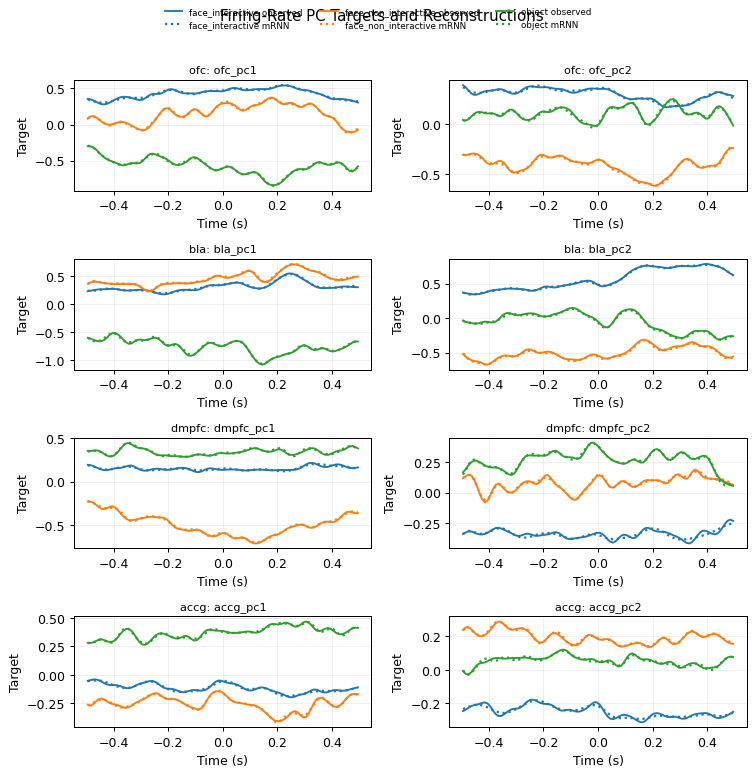

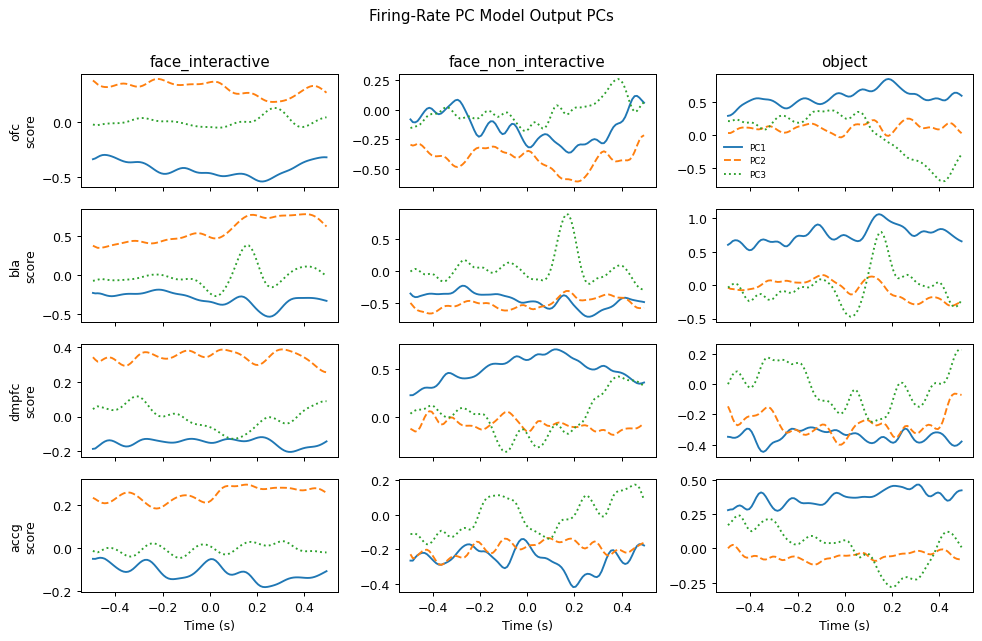

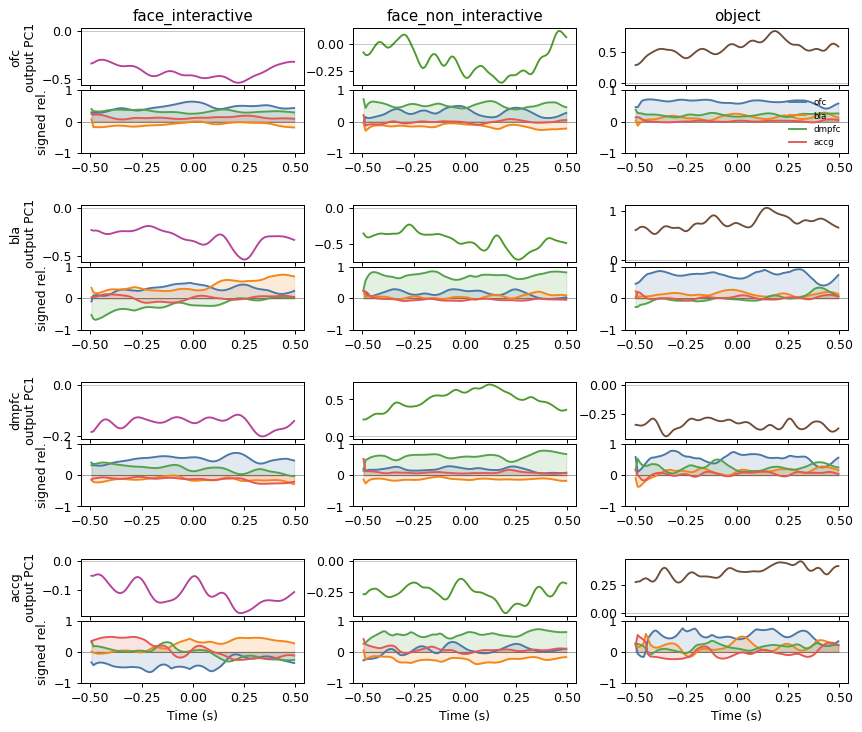

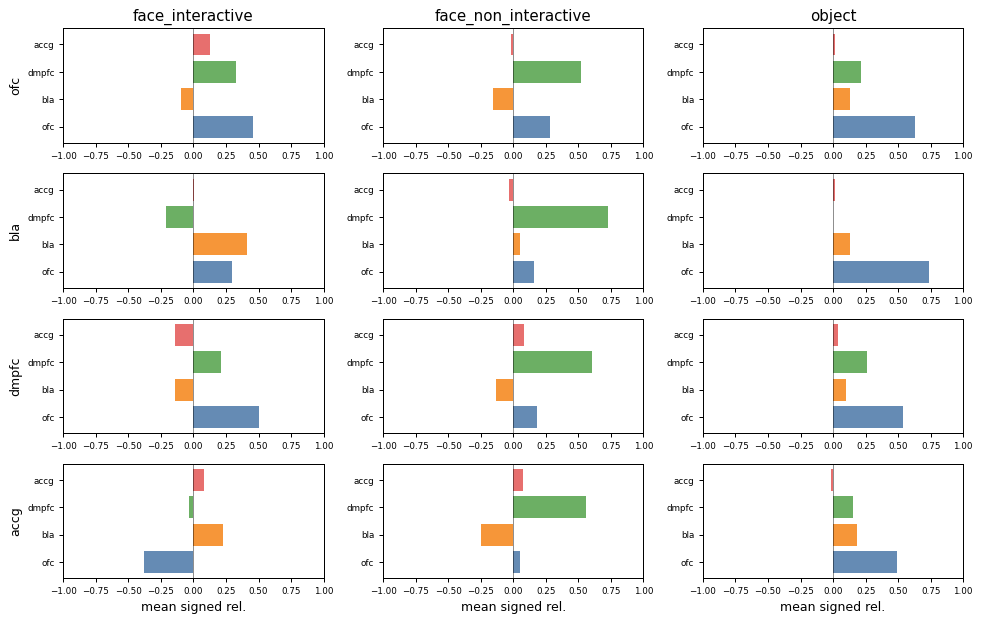

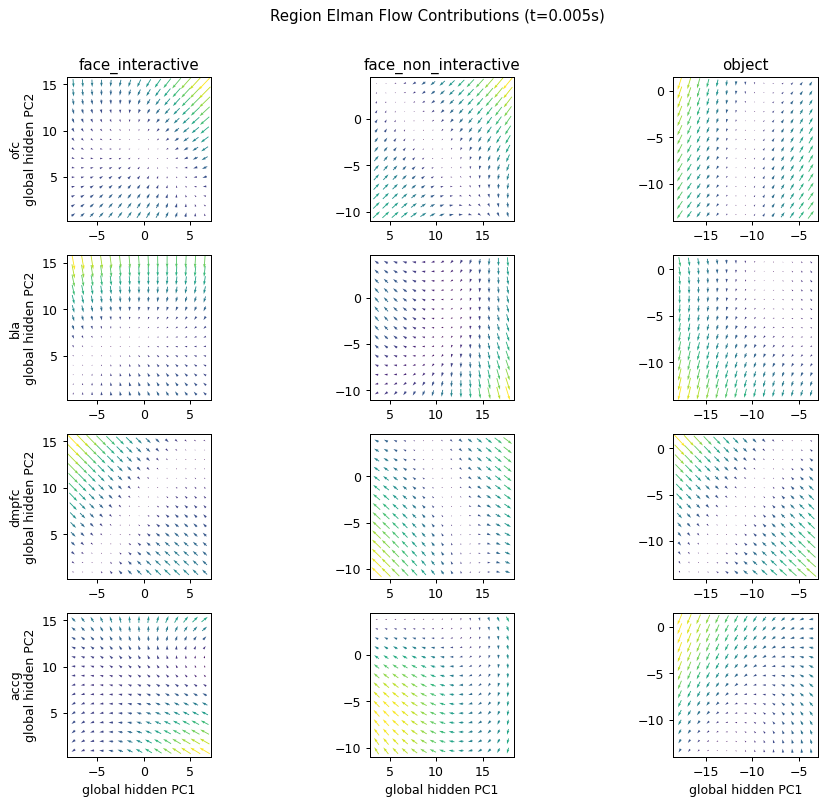

In [8]:
plot_settings = FixationMRNNDiagnosticPlotSettings()
plot_reconstructions(pc_replay, "Firing-Rate PC Targets and Reconstructions", max_features=2)
plot_output_pcs(pc_replay, "Firing-Rate PC Model Output PCs")
pc_signal_fig, pc_signal_axes = plot_fixation_mrnn_signal_evolution(pc_replay, settings=plot_settings)
display_figure(pc_signal_fig)
pc_bar_fig, pc_bar_axes = plot_fixation_mrnn_average_current_influence_bars(pc_replay, settings=plot_settings)
display_figure(pc_bar_fig)
pc_flow_fig, pc_flow_axes = plot_fixation_mrnn_flow_fields_at_time(pc_replay, settings=plot_settings, grid_points=15)
display_figure(pc_flow_fig)

## 7. Multiple Initializations

To run multiple initializations, set `initialization_mode = "multiple"` and choose `n_initializations`. The seed list is written to `seed_plan.json` in the scratch output directory and reused on reruns unless `overwrite_seed_plan` is set to `True`.

In [9]:
# multi_settings = settings_from_config(cfg)
# multi_settings.dataset_cfg_path = settings.dataset_cfg_path
# multi_settings.target_mode = "raw_fr"
# multi_settings.initialization_mode = "multiple"
# multi_settings.n_initializations = 100
# multi_settings.overwrite_seed_plan = False
# multi_result = train_fixation_mrnn_scratch(multi_settings, scratch_id="raw_fr_100init", overwrite=True)